## 1. Import Libraries

In [1]:
# ==========================================================
# Mutual Fund Performance Analytics
# Bluestock Internship - Day 4
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

## 2. Load Data

In [2]:
# ==========================================================
# Load Processed Datasets
# ==========================================================

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

### Task-1 : Compute daily returns 

In [3]:
# ==========================================================
# Step 1 — Inspect the Data
# ==========================================================
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.info()
nav.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


(46000, 3)

In [5]:
# ==========================================================
# Step 2 — Convert Date Column
# ==========================================================

nav["date"] = pd.to_datetime(nav["date"])

In [6]:
nav.dtypes

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

In [7]:
# ==========================================================
# Step 3 — Sort the Data
# ==========================================================

nav = nav.sort_values(
    by=["amfi_code", "date"]
)

In [8]:
# ==========================================================
# Step 4 — Calculate Daily Returns
# ==========================================================

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [9]:
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [10]:
# ==========================================================
# Step 5 — Merge Scheme Names
# ==========================================================

nav_returns = nav.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [11]:
nav_returns.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [12]:
# ==========================================================
# Step 6 — Validate the Distribution
# ==========================================================

nav_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

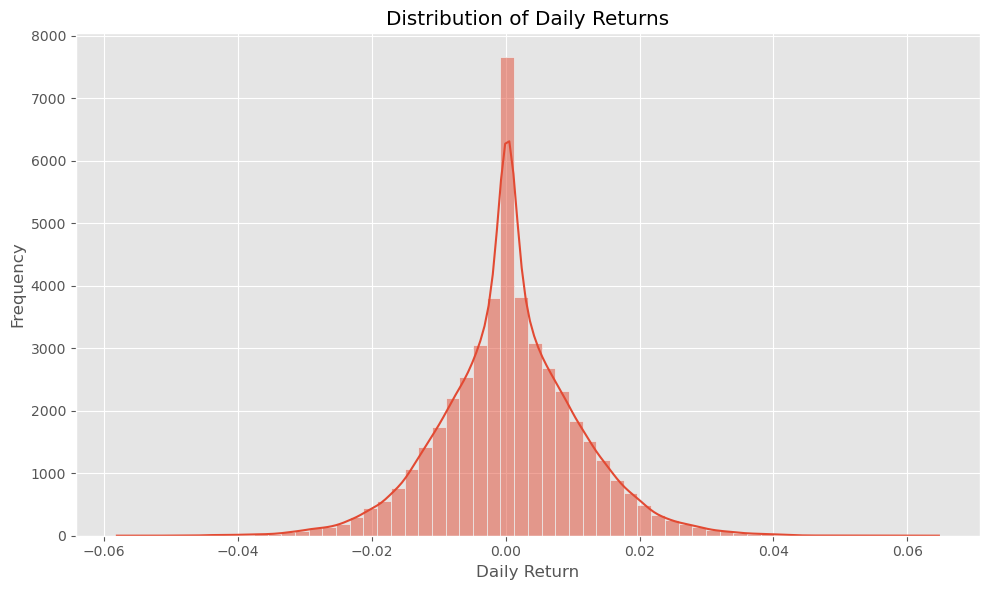

In [13]:
# ==========================================================
# Step 7 — Visualize the Distribution
# ==========================================================


plt.figure(figsize=(10,6))

sns.histplot(
    nav_returns["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")


plt.tight_layout()
plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ==========================================================
# Step 8 — Identify Extreme Returns
# ==========================================================


print("Highest Daily Returns")

display(
    nav_returns.nlargest(
        10,
        "daily_return"
    )[
        ["scheme_name", "date", "daily_return"]
    ]
)

Highest Daily Returns


,scheme_name,date,daily_return
24745,SBI Small Cap Fund - Regular Plan - Growth,2024-04-15,0.064713
13226,Nippon India Small Cap Fund - Regular - Growth,2024-03-19,0.059304
5207,ABSL Small Cap Fund - Regular - Growth,2024-05-01,0.054851
25566,SBI Small Cap Fund - Direct Plan - Growth,2023-01-10,0.053320
25832,SBI Small Cap Fund - Direct Plan - Growth,2024-01-17,0.051811
24155,SBI Small Cap Fund - Regular Plan - Growth,2022-01-10,0.051113
24371,SBI Small Cap Fund - Regular Plan - Growth,2022-11-08,0.049051
45082,DSP Small Cap Fund - Regular - Growth,2022-11-23,0.048490
24356,SBI Small Cap Fund - Regular Plan - Growth,2022-10-18,0.048454
25091,SBI Small Cap Fund - Regular Plan - Growth,2025-08-12,0.047123


In [15]:
print("Lowest Daily Returns")

display(
    nav_returns.nsmallest(
        10,
        "daily_return"
    )[
        ["scheme_name", "date", "daily_return"]
    ]
)

Lowest Daily Returns


,scheme_name,date,daily_return
12774,Nippon India Small Cap Fund - Regular - Growth,2022-06-24,-0.058102
4917,ABSL Small Cap Fund - Regular - Growth,2023-03-22,-0.051847
12952,Nippon India Small Cap Fund - Regular - Growth,2023-03-01,-0.050335
45312,DSP Small Cap Fund - Regular - Growth,2023-10-11,-0.048870
5560,ABSL Small Cap Fund - Regular - Growth,2025-09-08,-0.048634
19804,Axis Small Cap Fund - Regular - Growth,2022-12-23,-0.048367
13333,Nippon India Small Cap Fund - Regular - Growth,2024-08-15,-0.048305
20307,Axis Small Cap Fund - Regular - Growth,2024-11-27,-0.046524
26048,SBI Small Cap Fund - Direct Plan - Growth,2024-11-14,-0.045429
38520,HDFC Mid-Cap Opportunities Fund - Direct - Growth,2024-03-11,-0.045218


In [16]:
# ==========================================================
# Save Daily Returns Data
# ==========================================================

nav_returns.to_csv(
    "../reports/nav_returns.csv",
    index=False
)

print("nav_returns.csv saved successfully.")

nav_returns.csv saved successfully.


### Insight :
##### Daily returns were computed for all 40 mutual fund schemes using percentage change in NAV. The distribution is centered close to zero with both positive and negative daily movements, indicating realistic market behavior. The calculated daily returns will serve as the base for risk-adjusted performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Tracking Error in the subsequent analyses.

### Task-2 : Compute CAGR for 1yr, 3yr, 5yr 

In [17]:
# ==========================================================
#  Step 1 — Create a Function CAGR (1Y, 3Y, 5Y)
# ==========================================================

def calculate_cagr(start_nav, end_nav, years):
    """
    Calculate Compound Annual Growth Rate
    """

    return (end_nav / start_nav) ** (1 / years) - 1

In [18]:
# ==========================================================
#  Step 2 — Sort NAV Data
# ==========================================================

nav_returns = nav_returns.sort_values(
    ["amfi_code", "date"]
)

In [19]:
# ==========================================================
#  Step 3 — Latest Date
# ==========================================================

latest_date = nav_returns["date"].max()

print("Latest Date :", latest_date)

Latest Date : 2026-05-29 00:00:00


In [20]:
# ==========================================================
#  Step 4 — Empty List
# ==========================================================

cagr_results = []

In [21]:
# ==========================================================
#  Step 5 — Loop Through Every Fund
# ==========================================================

for fund in nav_returns["amfi_code"].unique():

    # Filter one fund

    fund_df = nav_returns[
        nav_returns["amfi_code"] == fund
    ].copy()

    # Sort by date

    fund_df = fund_df.sort_values("date")

    # Latest NAV

    latest_nav = fund_df.iloc[-1]["nav"]

    # Latest Scheme Name

    scheme = fund_df.iloc[-1]["scheme_name"]

    result = {
        "amfi_code": fund,
        "scheme_name": scheme
    }

    # Calculate CAGR

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        history = fund_df[
            fund_df["date"] <= target_date
        ]

        if history.empty:

            result[f"CAGR_{years}Y"] = np.nan

        else:

            start_nav = history.iloc[-1]["nav"]

            result[f"CAGR_{years}Y"] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            ) * 100

    cagr_results.append(result)

In [22]:
# ==========================================================
#  Step 6 — Create DataFrame
# ==========================================================

cagr_df = pd.DataFrame(cagr_results)

In [23]:
print(cagr_df.shape)

cagr_df.head()

(40, 5)


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,NaN


In [24]:
# ==========================================================
#  Step 7 — Sort by Best 3-Year CAGR
# ==========================================================

cagr_df = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
)

In [25]:
# ==========================================================
#  Step 8 — Display Comparison Table
# ==========================================================

cagr_df

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,NaN


In [26]:
print("Top 10 Funds by 3-Year CAGR")

display(
    cagr_df[
        ["scheme_name", "CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]
    ].head(10)
)

Top 10 Funds by 3-Year CAGR


,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,NaN
34,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,NaN
24,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,NaN
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN
25,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,NaN
19,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,NaN
30,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,NaN
36,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,NaN
3,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN
39,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,NaN


In [27]:
# ==========================================================
#  Step 9 — Visualization
# ==========================================================

top10 = cagr_df.head(10)

C:\Users\Utsav\AppData\Local\Temp\ipykernel_11656\3488114371.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


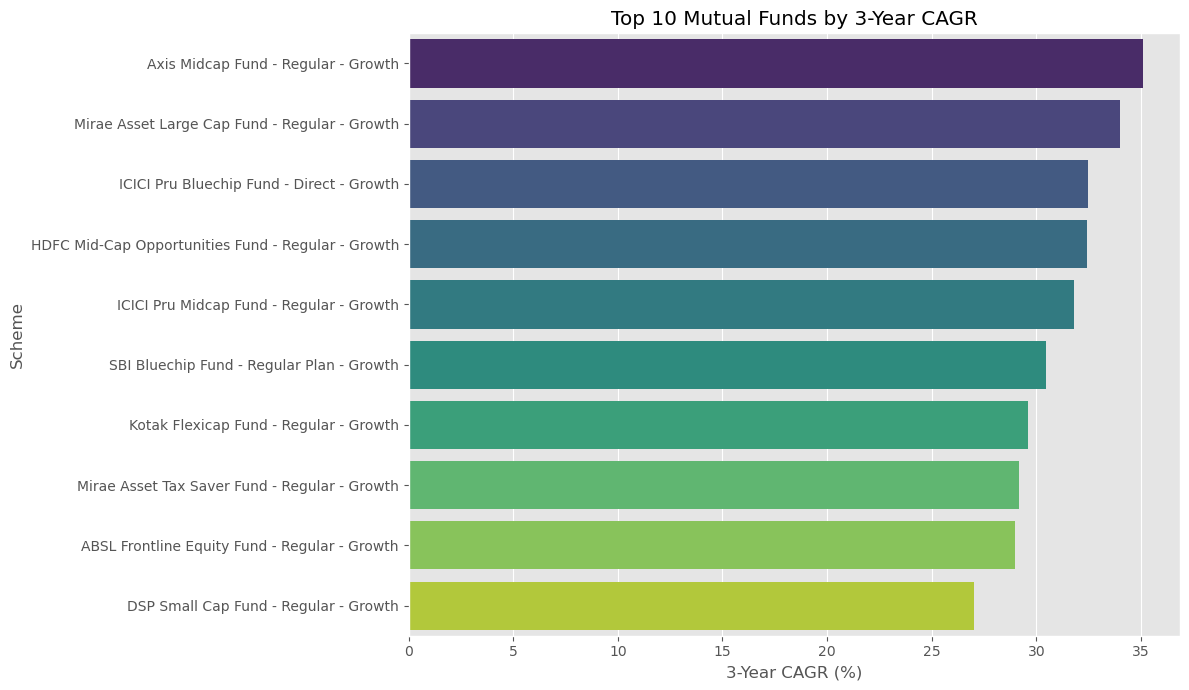

In [28]:

plt.figure(figsize=(12,7))

sns.barplot(
    data=top10,
    x="CAGR_3Y",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Mutual Funds by 3-Year CAGR")

plt.xlabel("3-Year CAGR (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/cagr_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# ==========================================================
#  Step 10 — Save Comparison Table
# ==========================================================

cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

### Insight :
##### The CAGR analysis compares the annualized growth of all mutual fund schemes over different investment horizons. Among the evaluated schemes, Axis Midcap Fund - Regular - Growth achieved the highest 3-year CAGR (≈35%), followed by Mirae Asset Large Cap Fund - Regular - Growth and ICICI Prudential Bluechip Fund - Direct - Growth. Since the available NAV history spans approximately 2022–2026, a complete 5-year CAGR could not be computed, resulting in missing (NaN) values for that column.

### Task-3 : Sharpe Ratio

In [30]:
# ==========================================================
#  Step 1 — Risk-Free Rate
# ==========================================================

# Annual Risk-Free Rate
risk_free_rate = 0.065

# Convert to Daily Rate
daily_rf = risk_free_rate / 252

print("Daily Risk Free Rate :", daily_rf)

Daily Risk Free Rate : 0.00025793650793650796


In [31]:
# ==========================================================
#  Step 2 — Create Empty List
# ==========================================================

sharpe_results = []

In [32]:
# ==========================================================
#  Step 3 — Calculate Sharpe Ratio for Every Fund
# ==========================================================

for amfi_code, fund_df in nav_returns.groupby("amfi_code"):

    # Remove first NaN return
    returns = fund_df["daily_return"].dropna()

    # Skip if insufficient data
    if len(returns) < 2:
        continue

    # Scheme Name
    scheme_name = fund_df["scheme_name"].iloc[0]

    # Average Daily Return
    mean_return = returns.mean()

    # Daily Risk
    std_return = returns.std()

    # Sharpe Ratio
    sharpe_ratio = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "Sharpe_Ratio": sharpe_ratio
    })

In [33]:
# ==========================================================
#  Step 4 — Create DataFrame
# ==========================================================

sharpe_df = pd.DataFrame(sharpe_results)

In [34]:
# ==========================================================
#  Step 5 — Verify
# ==========================================================

print(sharpe_df.shape)

(40, 3)


In [35]:
# ==========================================================
#  Step 6 — Rank Funds
# ==========================================================

sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Rank"] = sharpe_df.index + 1

In [36]:
# ==========================================================
#  Step 7 — Display
# ==========================================================

sharpe_df

,amfi_code,scheme_name,Sharpe_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1
1,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5
5,149323,DSP Midcap Fund - Regular - Growth,1.132122,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,10


In [37]:
# ==========================================================
#  Step 8 — Top 10
# ==========================================================

top10_sharpe = sharpe_df.head(10)

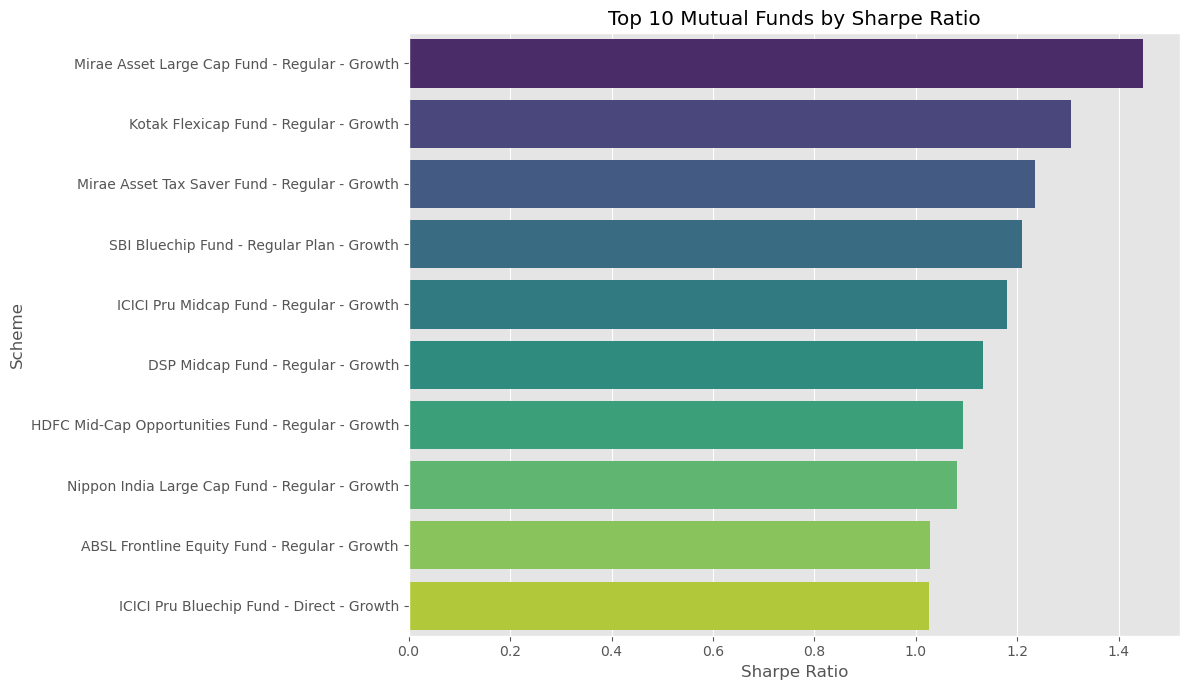

In [38]:
# ==========================================================
#  Step 9 — Plot
# ==========================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=top10_sharpe,
    x="Sharpe_Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# ==========================================================
#  Step 10 — Save CSV
# ==========================================================

sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

### Insight :
##### The Sharpe Ratio measures the risk-adjusted return of each mutual fund by comparing excess return over the risk-free rate with the volatility of daily returns. Funds with higher Sharpe Ratios provide better returns per unit of risk and are considered more efficient investments. The top-ranked funds from this analysis will be used later while constructing the overall Fund Scorecard.

### Task - 4 : Sortino Ratio

In [40]:
# ==========================================================
# Step 1 — Load Daily Returns
# ==========================================================

nav_returns = pd.read_csv("../reports/nav_returns.csv")

nav_returns["date"] = pd.to_datetime(nav_returns["date"])

In [41]:
# ==========================================================
# Step 2 — Risk-Free Rate
# ==========================================================

risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [42]:
# ==========================================================
# Step 3 — Empty List
# ==========================================================

sortino_results = []

In [43]:
# ==========================================================
# Step 4 — Calculate Sortino Ratio
# ==========================================================

for amfi_code, fund_df in nav_returns.groupby("amfi_code"):

    # Daily Returns
    returns = fund_df["daily_return"].dropna()

    # Skip if not enough observations
    if len(returns) < 2:
        continue

    # Scheme Name
    scheme_name = fund_df["scheme_name"].iloc[0]

    # Mean Return
    mean_return = returns.mean()

    # Only Negative Returns
    downside_returns = returns[returns < 0]

    # Skip if no downside returns
    if len(downside_returns) < 2:
        continue

    # Downside Standard Deviation
    downside_std = downside_returns.std()

    # Sortino Ratio
    sortino_ratio = (
        (mean_return - daily_rf)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "Sortino_Ratio": sortino_ratio
    })

In [44]:
# ==========================================================
# Step 5 — Create DataFrame
# ==========================================================

sortino_df = pd.DataFrame(sortino_results)

In [45]:
# ==========================================================
# Step 6 — Verify
# ==========================================================

print(sortino_df.shape)

(40, 3)


In [46]:
# ==========================================================
# Step 7 — Rank Funds
# ==========================================================

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = sortino_df.index + 1

In [47]:
# ==========================================================
# Step 8 — Display
# ==========================================================

sortino_df

,amfi_code,scheme_name,Sortino_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644,1
1,120843,Kotak Flexicap Fund - Regular - Growth,2.364320,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353,5
5,149323,DSP Midcap Fund - Regular - Growth,1.875101,6
6,118632,Nippon India Large Cap Fund - Regular - Growth,1.850133,7
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134,8
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805294,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563,10


In [48]:
# ==========================================================
# Step 9 — Top 10
# ==========================================================

top10_sortino = sortino_df.head(10)

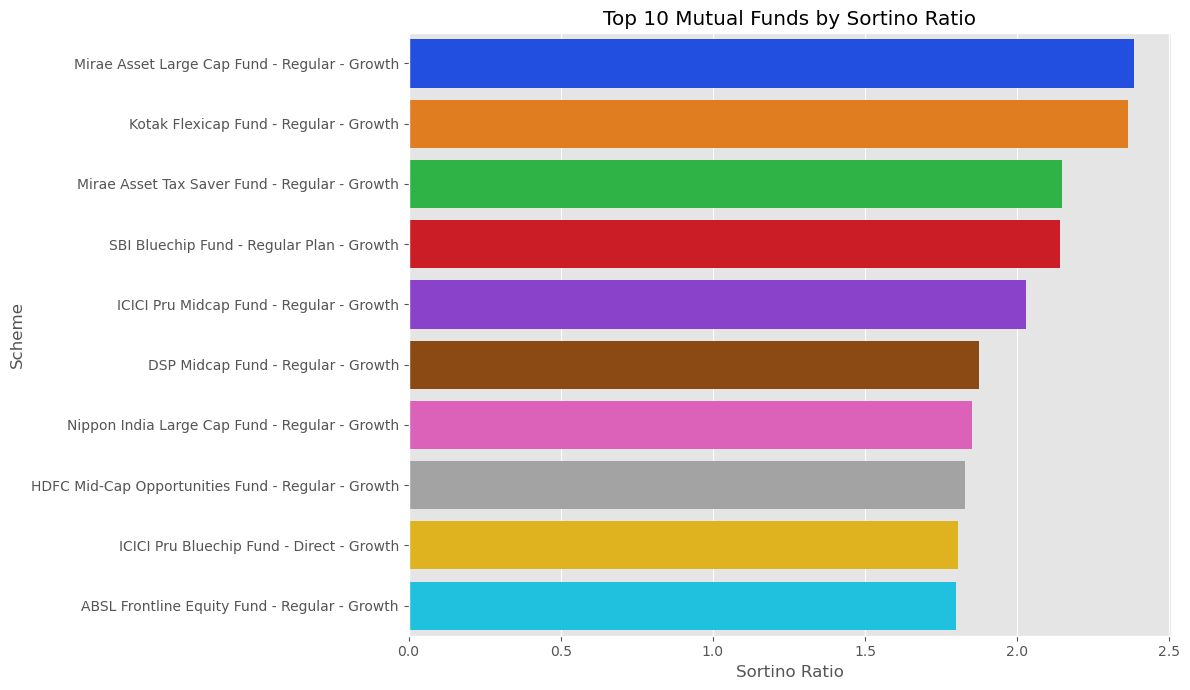

In [49]:
# ==========================================================
# Step 10 — Visualization
# ==========================================================
plt.figure(figsize=(12,7))

sns.barplot(
    data=top10_sortino,
    x="Sortino_Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="bright",
    legend=False
)

plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
# ==========================================================
# Step 11 — Save CSV
# ==========================================================

sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

### Insight:
##### The Sortino Ratio measures the risk-adjusted performance of mutual funds by considering only downside volatility. Unlike the Sharpe Ratio, it ignores positive fluctuations and focuses solely on negative return days. Funds with higher Sortino Ratios demonstrate stronger returns while effectively controlling downside risk, making them more attractive for risk-conscious investors.

In [51]:
print(sortino_df.shape)

sortino_df.head()

(40, 4)


,amfi_code,scheme_name,Sortino_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644,1
1,120843,Kotak Flexicap Fund - Regular - Growth,2.364320,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353,5


### Task - 5 : Alpha and Beta

In [52]:
# ==========================================================
# Step 1 — Load Benchmark Dataset
# ==========================================================

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv"
)

In [53]:
# ==========================================================
# Step 2 — Check Columns
# ==========================================================

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [54]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [55]:
# ==========================================================
# Step 3 — Prepare Benchmark Data
# ==========================================================

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

In [56]:
# ==========================================================
# Step 4 — Select NIFTY100
# ==========================================================

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [57]:
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [58]:
# ==========================================================
# Step 5 — Calculate Benchmark Daily Return
# ==========================================================

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [59]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [60]:
# ==========================================================
# Step 6 — Keep Required Columns
# ==========================================================

nifty100 = nifty100[
    [
        "date",
        "benchmark_return"
    ]
]

In [61]:
# ==========================================================
# Step 7 — Merge Fund Returns with Benchmark
# ==========================================================

merged_returns = nav_returns.merge(
    nifty100,
    on="date",
    how="inner"
)


In [62]:
# ==========================================================
# Step 8 — Verify
# ==========================================================

print(merged_returns.shape)

merged_returns.head()

(46000, 6)


,amfi_code,date,nav,daily_return,scheme_name,benchmark_return
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,NaN
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,-0.013540
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,0.004003
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,0.006150


In [63]:
# ==========================================================
# Step 9 — Empty List
# ==========================================================

alpha_beta_results = []

In [64]:
# ==========================================================
# Step 10 — Regression
# ==========================================================

from scipy.stats import linregress

for amfi_code, fund_df in merged_returns.groupby("amfi_code"):

    data = fund_df.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    if len(data) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(

        data["benchmark_return"],

        data["daily_return"]

    )

    alpha_beta_results.append({

        "amfi_code": amfi_code,

        "scheme_name": data["scheme_name"].iloc[0],

        "Alpha": intercept * 252,

        "Beta": slope

    })

In [65]:
# ==========================================================
# Step 11 — Create DataFrame
# ==========================================================

alpha_beta_df = pd.DataFrame(alpha_beta_results)

In [66]:
print(alpha_beta_df.shape)

alpha_beta_df.head()

(40, 4)


,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [67]:
# ==========================================================
# Step 12 — Rank by Alpha
# ==========================================================

alpha_beta_df = alpha_beta_df.sort_values(

    by="Alpha",

    ascending=False

).reset_index(drop=True)

In [68]:
# ==========================================================
# Step 13 — Add Rank
# ==========================================================

alpha_beta_df["Rank"] = (
    alpha_beta_df.index + 1
)

In [69]:
# ==========================================================
# Step 14 — Display
# ==========================================================

alpha_beta_df

,amfi_code,scheme_name,Alpha,Beta,Rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1
1,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,3
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,4
4,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,5
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,6
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,7
7,149323,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523,8
8,119094,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265,9
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751,10


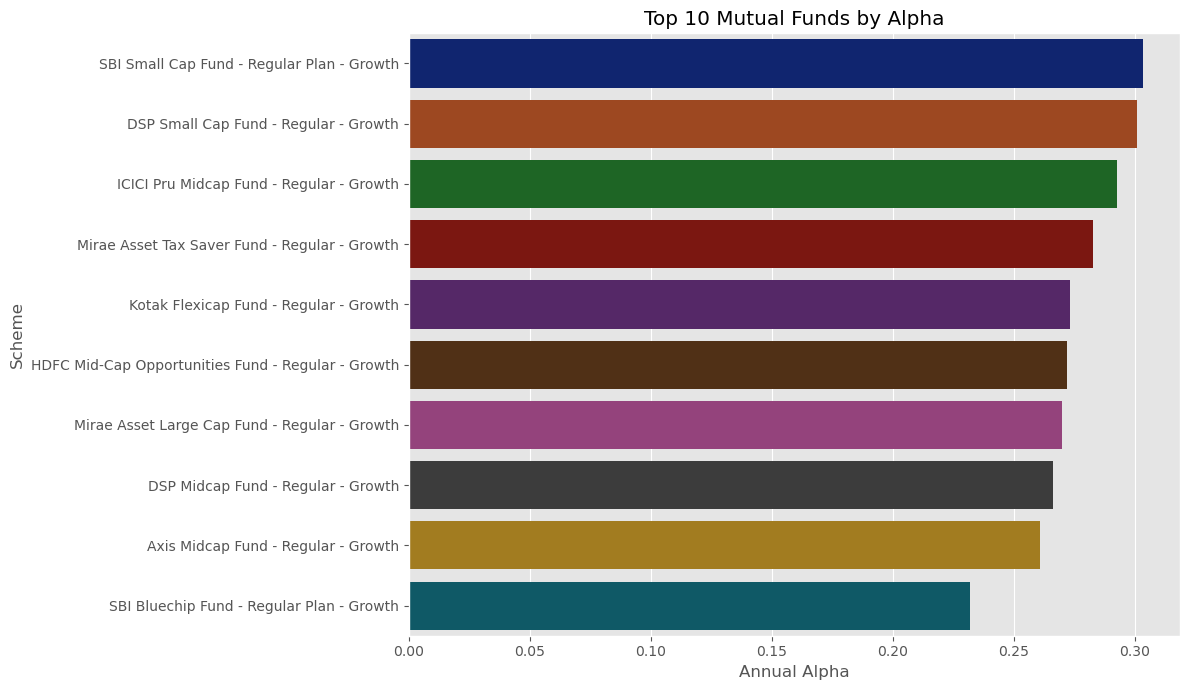

In [70]:
# ==========================================================
# Step 15 — Visualization
# ==========================================================


top10_alpha = alpha_beta_df.head(10)

plt.figure(figsize=(12,7))

sns.barplot(

    data=top10_alpha,

    x="Alpha",

    y="scheme_name",

    hue="scheme_name",

    palette="dark",

    legend=False

)

plt.title("Top 10 Mutual Funds by Alpha")

plt.xlabel("Annual Alpha")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(

    "../reports/charts/alpha_beta.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [71]:
# ==========================================================
# Step 16 — Save CSV (Deliverable)
# ==========================================================

alpha_beta_df.to_csv(

    "../reports/alpha_beta.csv",

    index=False

)

### Insight:
##### Alpha and Beta were estimated using Ordinary Least Squares (OLS) regression of each mutual fund's daily returns against the NIFTY100 benchmark returns. Beta measures the sensitivity of a fund to market movements, while Alpha represents the annualized excess return after accounting for market risk. Funds with higher Alpha values have outperformed the benchmark on a risk-adjusted basis, whereas Beta indicates whether a fund is more or less volatile than the market.

### Task-6 : Maximum Drawdown

In [72]:
# ==========================================================
# Step 1 — Load Data
# ==========================================================

nav_returns = pd.read_csv("../reports/nav_returns.csv")

nav_returns["date"] = pd.to_datetime(nav_returns["date"])

In [73]:
# ==========================================================
# Step 2 — Empty List
# ==========================================================

drawdown_results = []

In [74]:
# ==========================================================
# Step 3 — Calculate Maximum Drawdown
# ==========================================================

for amfi_code, fund_df in nav_returns.groupby("amfi_code"):

    fund_df = fund_df.sort_values("date").copy()

    scheme_name = fund_df["scheme_name"].iloc[0]

    # Running Maximum NAV
    fund_df["running_max"] = fund_df["nav"].cummax()

    # Drawdown
    fund_df["drawdown"] = (
        fund_df["nav"] /
        fund_df["running_max"]
    ) - 1

    # Worst Drawdown
    worst_idx = fund_df["drawdown"].idxmin()

    worst_drawdown = fund_df.loc[
        worst_idx,
        "drawdown"
    ]

    # Bottom Date
    bottom_date = fund_df.loc[
        worst_idx,
        "date"
    ]

    # Peak Date (date of running maximum before the bottom)
    peak_date = fund_df.loc[
        :worst_idx
    ]["nav"].idxmax()

    peak_date = fund_df.loc[
        peak_date,
        "date"
    ]

    drawdown_results.append({

        "amfi_code": amfi_code,

        "scheme_name": scheme_name,

        "Max_Drawdown": worst_drawdown * 100,

        "Peak_Date": peak_date,

        "Bottom_Date": bottom_date

    })

In [75]:
# ==========================================================
# Step 4 — Create DataFrame
# ==========================================================

drawdown_df = pd.DataFrame(drawdown_results)

In [76]:
# ==========================================================
# Step 5 — Verify
# ==========================================================

print(drawdown_df.shape)

drawdown_df.head()

(40, 5)


,amfi_code,scheme_name,Max_Drawdown,Peak_Date,Bottom_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.308264,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.217209,2022-03-11,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.291596,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.446916,2024-11-21,2026-05-11


In [77]:
# ==========================================================
# Step 6 — Rank
# ==========================================================

drawdown_df = drawdown_df.sort_values(
    by="Max_Drawdown",
    ascending=False
).reset_index(drop=True)

drawdown_df["Rank"] = drawdown_df.index + 1

In [78]:
# ==========================================================
# Step 7 — Display
# ==========================================================

drawdown_df

,amfi_code,scheme_name,Max_Drawdown,Peak_Date,Bottom_Date,Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.097731,2025-10-16,2025-10-20,1
1,120844,Kotak Liquid Fund - Regular - Growth,-0.116293,2024-04-12,2024-04-30,2
2,101208,ABSL Liquid Fund - Regular - Growth,-0.162250,2023-09-05,2023-09-12,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.308264,2023-05-23,2023-07-28,4
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-4.328729,2024-09-16,2025-04-01,5
5,118636,Nippon India Gilt Securities Fund - Regular - ...,-8.316362,2023-02-09,2024-02-09,6
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-10.859862,2022-02-03,2022-03-29,7
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,-11.265729,2023-07-11,2023-10-20,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.291596,2023-04-24,2023-07-05,9
9,118635,Nippon India ETF Nifty 50 BeES,-11.650625,2022-01-03,2022-06-09,10


In [79]:
# ==========================================================
# Step 8 — Top 10 Funds
# ==========================================================

top10_drawdown = drawdown_df.head(10)

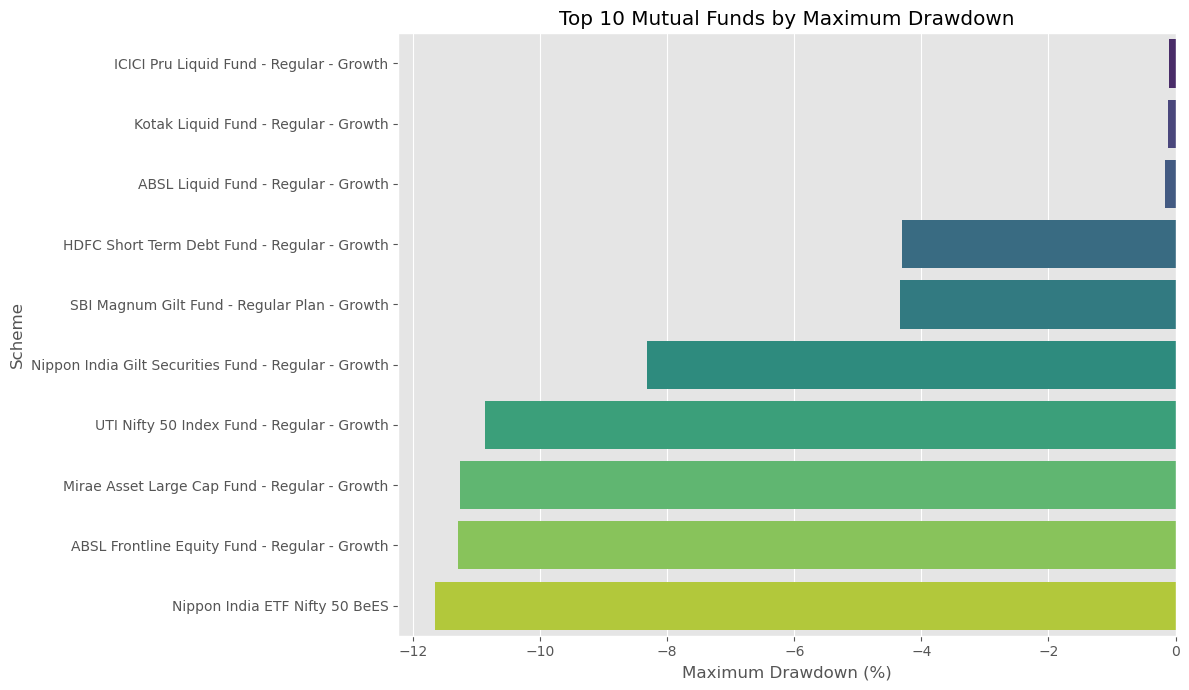

In [80]:
# ==========================================================
# Step 9 — Visualization
# ==========================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=top10_drawdown,
    x="Max_Drawdown",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Mutual Funds by Maximum Drawdown")

plt.xlabel("Maximum Drawdown (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
# ==========================================================
# Step 10 — Save CSV
# ==========================================================


drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

### Insight:
##### Maximum Drawdown measures the largest historical decline in NAV from a previous peak. Funds with smaller drawdowns indicate better downside protection during market corrections. Along with Sharpe Ratio, Sortino Ratio, and Alpha, Maximum Drawdown is an important risk metric and will contribute to the overall Fund Scorecard in the next task.

### Task-7 : Fund Scorecard (0–100)

In [82]:
# ==========================================================
# Step 1 — Required DataFrames
# ==========================================================
## already used previousely

In [83]:
# ==========================================================
# Step 2 — Get Expense Ratio
# ==========================================================

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [84]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [85]:
# ==========================================================
# Step 3 — Merge All Metrics
# ==========================================================

scorecard = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_3Y"
    ]
].copy()

# Sharpe
scorecard = scorecard.merge(
    sharpe_df[
        [
            "amfi_code",
            "Sharpe_Ratio"
        ]
    ],
    on="amfi_code"
)

# Alpha
scorecard = scorecard.merge(
    alpha_beta_df[
        [
            "amfi_code",
            "Alpha"
        ]
    ],
    on="amfi_code"
)

# Maximum Drawdown
scorecard = scorecard.merge(
    drawdown_df[
        [
            "amfi_code",
            "Max_Drawdown"
        ]
    ],
    on="amfi_code"
)

# Expense Ratio
scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

In [86]:
# ==========================================================
# Step 4 — Create Rankings
# ==========================================================

# Higher CAGR is better
scorecard["CAGR_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False,
    method="dense"
)

# Higher Sharpe is better
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False,
    method="dense"
)

# Higher Alpha is better
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False,
    method="dense"
)

# Lower Expense Ratio is better
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

# Smaller drawdown (less negative) is better
scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(
    ascending=False,
    method="dense"
)

In [87]:
# ==========================================================
# Step 5 — Weighted Score
# ==========================================================

scorecard["Weighted_Score"] = (
      scorecard["CAGR_Rank"] * 0.30
    + scorecard["Sharpe_Rank"] * 0.25
    + scorecard["Alpha_Rank"] * 0.20
    + scorecard["Expense_Rank"] * 0.15
    + scorecard["Drawdown_Rank"] * 0.10
)

In [88]:
# ==========================================================
# Step 6 — Normalize (0-100)
# ==========================================================

max_score = scorecard["Weighted_Score"].max()
min_score = scorecard["Weighted_Score"].min()

scorecard["Fund_Score"] = (
    (max_score - scorecard["Weighted_Score"])
    /
    (max_score - min_score)
) * 100

In [89]:
# ==========================================================
# Step 7 - Overall Ranking
# ==========================================================

scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

In [90]:
# ==========================================================
# Step 8 — Final Output
# ==========================================================

scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "Fund_Score",
        "CAGR_3Y",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Max_Drawdown"
    ]
].head(10)

,Overall_Rank,scheme_name,Fund_Score,CAGR_3Y,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown
0,1,Mirae Asset Large Cap Fund - Regular - Growth,100.000000,34.000916,1.448291,0.269838,1.46,-11.265729
1,2,Kotak Flexicap Fund - Regular - Growth,94.076655,29.582770,1.306744,0.273305,1.45,-12.973968
2,3,ICICI Pru Midcap Fund - Regular - Growth,93.379791,31.777537,1.180101,0.292636,1.36,-18.188514
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,91.811847,32.442459,1.093699,0.271954,1.38,-16.217209
4,5,ICICI Pru Bluechip Fund - Direct - Growth,90.243902,32.487429,1.026524,0.211948,0.80,-12.588276
5,6,Axis Midcap Fund - Regular - Growth,86.585366,35.111802,0.998231,0.260767,1.38,-20.960884
6,7,SBI Bluechip Fund - Regular Plan - Growth,85.888502,30.456524,1.208267,0.232010,1.54,-15.012385
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,84.843206,29.178902,1.234930,0.282704,1.60,-16.396743
8,9,ABSL Frontline Equity Fund - Regular - Growth,77.177700,28.967695,1.027213,0.213998,1.60,-11.291596
9,10,DSP Midcap Fund - Regular - Growth,75.435540,26.869991,1.132122,0.265986,1.61,-17.248106


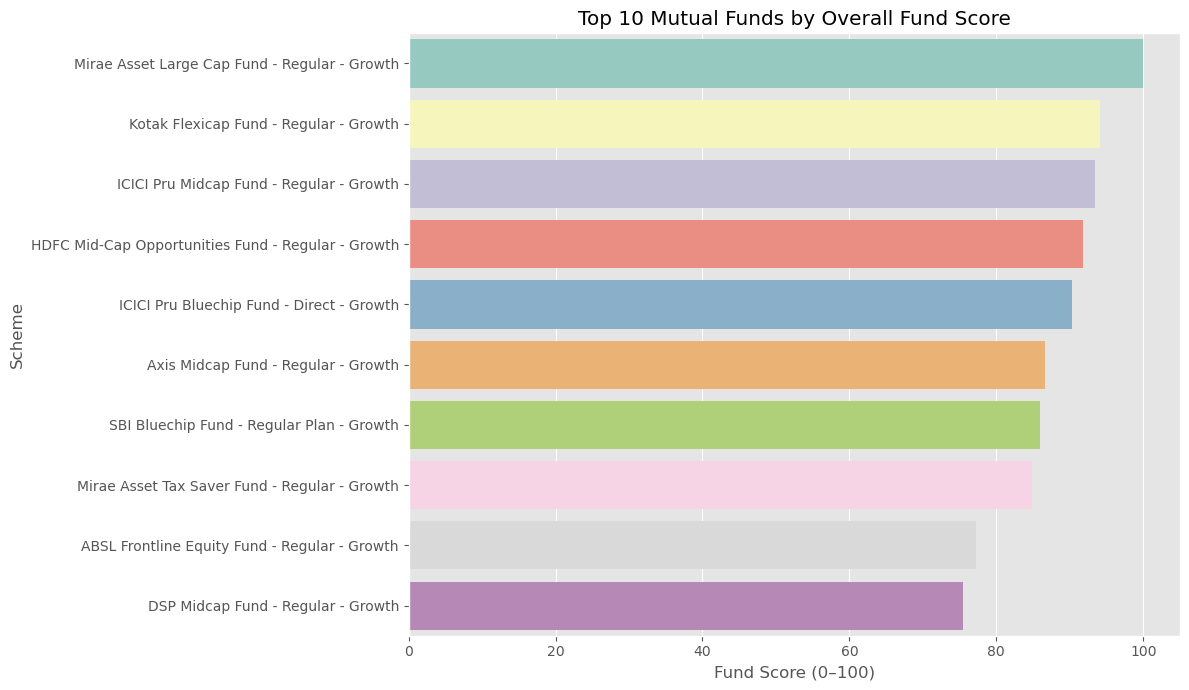

In [91]:
# ==========================================================
# Step 9 — Visualization
# ==========================================================

top10_score = scorecard.head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top10_score,
    x="Fund_Score",
    y="scheme_name",
    hue="scheme_name",
    palette="Set3",
    legend=False
)

plt.title("Top 10 Mutual Funds by Overall Fund Score")
plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
# ==========================================================
# Step 10 — Save Final Deliverable
# ==========================================================
fund_scorecard = scorecard[
    [
        "Overall_Rank",
        "amfi_code",
        "scheme_name",
        "Fund_Score",
        "CAGR_3Y",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Max_Drawdown"
    ]
]

fund_scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

### Insight:
##### A composite Fund Score (0–100) was created by combining five key performance metrics: 3-Year CAGR (30%), Sharpe Ratio (25%), Alpha (20%), Expense Ratio (15%), and Maximum Drawdown (10%). Each metric was converted into a rank, weighted according to its importance, and normalized to produce an overall score. Funds with higher scores demonstrate a stronger balance of return, risk-adjusted performance, cost efficiency, and downside protection.

### Task-8 : Benchmark comparison chart

In [93]:
# ==========================================================
# Step 1 — Select Top 5 Funds
# ==========================================================

top5_funds = scorecard.head(5)

top5_codes = top5_funds["amfi_code"].tolist()

top5_names = top5_funds["scheme_name"].tolist()

top5_funds

,amfi_code,scheme_name,CAGR_3Y,Sharpe_Ratio,Alpha,Max_Drawdown,expense_ratio_pct,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Weighted_Score,Fund_Score,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,1.448291,0.269838,-11.265729,1.46,2.0,1.0,7.0,20.0,8.0,6.05,100.000000,1
1,120843,Kotak Flexicap Fund - Regular - Growth,29.582770,1.306744,0.273305,-12.973968,1.45,7.0,2.0,5.0,19.0,13.0,7.75,94.076655,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,31.777537,1.180101,0.292636,-18.188514,1.36,5.0,5.0,3.0,14.0,25.0,7.95,93.379791,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,1.093699,0.271954,-16.217209,1.38,4.0,7.0,6.0,15.0,20.0,8.40,91.811847,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,1.026524,0.211948,-12.588276,0.80,3.0,10.0,13.0,11.0,12.0,8.85,90.243902,5


In [94]:
# ==========================================================
# Step 2 — Last 3 Years NAV
# ==========================================================

latest_date = nav_returns["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

In [95]:
fund_nav = nav_returns[
    (nav_returns["amfi_code"].isin(top5_codes)) &
    (nav_returns["date"] >= start_date)
].copy()

In [96]:
# ==========================================================
# Step 3 — Normalize NAV
# ==========================================================

fund_nav["Normalized_NAV"] = (
    fund_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [97]:
# ==========================================================
# Step 4 — Prepare Benchmarks
# ==========================================================

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark_recent = benchmark[
    benchmark["date"] >= start_date
].copy()

In [98]:
benchmark_recent["Normalized_Value"] = (
    benchmark_recent.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

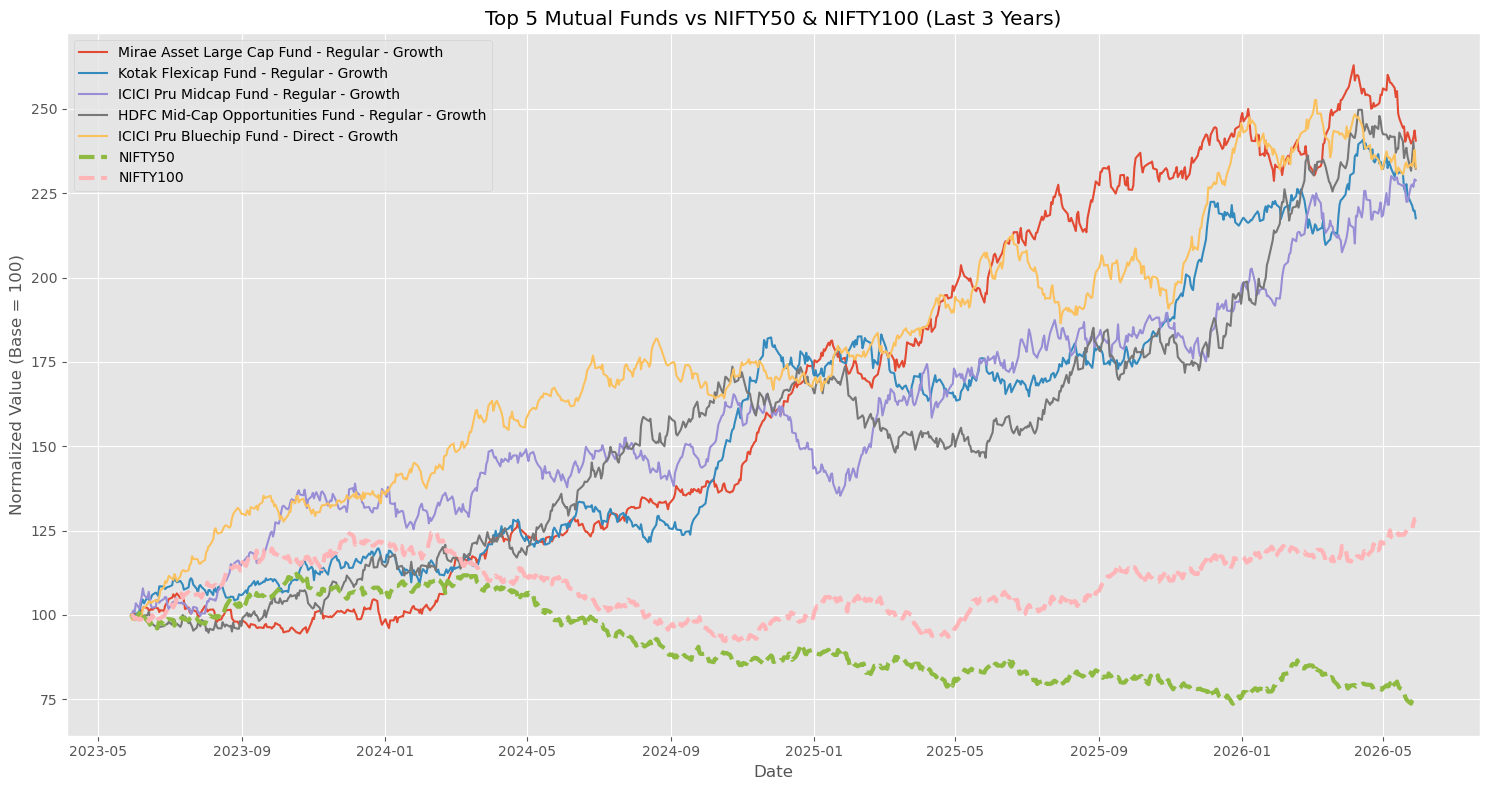

In [99]:
# ==========================================================
# Step 5 — Plot
# ==========================================================

plt.figure(figsize=(15,8))

# Top 5 Funds
for code in top5_codes:

    temp = fund_nav[
        fund_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=temp["scheme_name"].iloc[0]
    )

# Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_recent[
        benchmark_recent["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Value"],
        linestyle="--",
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
# ==========================================================
# Step 6 — NIFTY100 Daily Returns
# ==========================================================

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [101]:
# ==========================================================
# Step 7 — Empty List
# ==========================================================

tracking_results = []

In [102]:
# ==========================================================
# Step 8 — Calculate Tracking Error
# ==========================================================

for amfi_code, fund_df in nav_returns.groupby("amfi_code"):

    merged = fund_df.merge(
        nifty100[
            [
                "date",
                "benchmark_return"
            ]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append({

        "amfi_code": amfi_code,

        "scheme_name": merged["scheme_name"].iloc[0],

        "Tracking_Error": tracking_error

    })

In [103]:
# ==========================================================
# Step 9 — Create DataFrame
# ==========================================================

tracking_df = pd.DataFrame(tracking_results)

In [104]:
# ==========================================================
# Step 10 — Rank
# ==========================================================

tracking_df = tracking_df.sort_values(
    by="Tracking_Error",
    ascending=True
).reset_index(drop=True)

tracking_df["Rank"] = tracking_df.index + 1

In [105]:
# ==========================================================
# Step 11 — Display
# ==========================================================

tracking_df.head(10)

,amfi_code,scheme_name,Tracking_Error,Rank
0,101208,ABSL Liquid Fund - Regular - Growth,0.128957,1
1,120507,ICICI Pru Liquid Fund - Regular - Growth,0.129044,2
2,120844,Kotak Liquid Fund - Regular - Growth,0.129046,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,0.134535,4
4,118636,Nippon India Gilt Securities Fund - Regular - ...,0.134758,5
5,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.135646,6
6,118635,Nippon India ETF Nifty 50 BeES,0.183076,7
7,120841,Kotak Bluechip Fund - Regular - Growth,0.183119,8
8,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.183680,9
9,119093,Axis Bluechip Fund - Direct - Growth,0.187900,10


In [106]:
# ==========================================================
# Step 12 — Save CSV
# ==========================================================

tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

### Insight:
##### The performance of the top five mutual funds was compared with the NIFTY50 and NIFTY100 indices by normalizing all series to a common base value of 100 over the last three years. This allows relative growth to be compared regardless of absolute NAV or index levels. Tracking Error was calculated against the NIFTY100 benchmark using the annualized standard deviation of the difference between fund and benchmark daily returns. Lower tracking error indicates closer alignment with benchmark performance, while higher values indicate greater deviation.